In [1]:
import mmbra
import mmbracategories

import torch
import os
import scipy.io as sio

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.feature_selection import mutual_info_classif

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#Code from Google Collab



# load data
data_dir_root = os.path.join('./data', 'ThingsEEG-Text')
sbj = 'sub-10'
image_model = 'pytorch/cornet_s'
text_model = 'CLIPText'
roi = '17channels'

# getting directory and joining that
brain_dir = os.path.join(data_dir_root, 'brain_feature', roi, sbj)
image_dir_seen = os.path.join(data_dir_root, 'visual_feature/ThingsTrain', image_model, sbj)
image_dir_unseen = os.path.join(data_dir_root, 'visual_feature/ThingsTest', image_model, sbj)
text_dir_seen = os.path.join(data_dir_root, 'textual_feature/ThingsTrain/text', text_model, sbj)
text_dir_unseen = os.path.join(data_dir_root, 'textual_feature/ThingsTest/text', text_model, sbj)

# Data Loading

# set up directory by constructing data paths to the data sets
# organizes these paths based on the subject identifier, data type (training or testing), and the model used (e.g., image and text models).
# datasets are loaded from .mat files using the scipy.io.loadmat() function.
# function reads the data into numpy arrays, facilitating data manipulation.


# Data Preprocessing

# For the brain data, specific time intervals are extracted and the data is reshaped to a two-dimensional format to simplify analysis
# Image and text data are scaled to enhance numerical stability during model training
# Dimensionality reduction is applied to the image data to limit the number of features, making the dataset more manageable and reducing computational complexity

# Conversion to PyTorch Tensors

# The numpy arrays for each dataset (brain, image, text, and labels) are converted into PyTorch tensors. 
# This conversion is crucial for efficient data handling in neural network training, as tensors are optimized for operations on GPU.

brain_seen = sio.loadmat(os.path.join(brain_dir, 'eeg_train_data_within.mat'))['data'].astype('double') * 2.0
brain_seen = brain_seen[:,:,27:60] # 70ms-400ms
brain_seen = np.reshape(brain_seen, (brain_seen.shape[0], -1))
image_seen = sio.loadmat(os.path.join(image_dir_seen, 'feat_pca_train.mat'))['data'].astype('double')*50.0
text_seen = sio.loadmat(os.path.join(text_dir_seen, 'text_feat_train.mat'))['data'].astype('double')*2.0
label_seen = sio.loadmat(os.path.join(brain_dir, 'eeg_train_data_within.mat'))['class_idx'].T.astype('int')
image_seen = image_seen[:,0:100]

brain_unseen = sio.loadmat(os.path.join(brain_dir, 'eeg_test_data.mat'))['data'].astype('double')*2.0
brain_unseen = brain_unseen[:, :, 27:60]
brain_unseen = np.reshape(brain_unseen, (brain_unseen.shape[0], -1))
image_unseen = sio.loadmat(os.path.join(image_dir_unseen, 'feat_pca_test.mat'))['data'].astype('double')*50.0
text_unseen = sio.loadmat(os.path.join(text_dir_unseen, 'text_feat_test.mat'))['data'].astype('double')*2.0
label_unseen = sio.loadmat(os.path.join(brain_dir, 'eeg_test_data.mat'))['class_idx'].T.astype('int')
image_unseen = image_unseen[:, 0:100]

brain_seen = torch.from_numpy(brain_seen)
brain_unseen = torch.from_numpy(brain_unseen)
image_seen = torch.from_numpy(image_seen)
image_unseen = torch.from_numpy(image_unseen)
text_seen = torch.from_numpy(text_seen)
text_unseen = torch.from_numpy(text_unseen)
label_seen = torch.from_numpy(label_seen)
label_unseen = torch.from_numpy(label_unseen)

# Summary 

# The code prints the shape of each dataset, providing an overview of the number of samples and features for both training and testing sets. 
# This summary helps confirm that the data is correctly formatted and that the expected number of features is present. 
# This process of data loading, preprocessing, and conversion into PyTorch tensors ensures that the brain, image, and text datasets are ready for further analysis or machine learning tasks.

print('seen_brain_samples=', brain_seen.shape[0], ', seen_brain_features=', brain_seen.shape[1])
print('seen_image_samples=', image_seen.shape[0], ', seen_image_features=', image_seen.shape[1])
print('seen_text_samples=', text_seen.shape[0], ', seen_text_features=', text_seen.shape[1])
print('seen_label=', label_seen.shape)
print('unseen_brain_samples=', brain_unseen.shape[0], ', unseen_brain_features=', brain_unseen.shape[1])
print('unseen_image_samples=', image_unseen.shape[0], ', unseen_image_features=', image_unseen.shape[1])
print('unseen_text_samples=', text_unseen.shape[0], ', unseen_text_features=', text_unseen.shape[1])
print('unseen_label=', label_unseen.shape)

seen_brain_samples= 16540 , seen_brain_features= 561
seen_image_samples= 16540 , seen_image_features= 100
seen_text_samples= 16540 , seen_text_features= 512
seen_label= torch.Size([16540, 1])
unseen_brain_samples= 16000 , unseen_brain_features= 561
unseen_image_samples= 16000 , unseen_image_features= 100
unseen_text_samples= 16000 , unseen_text_features= 512
unseen_label= torch.Size([16000, 1])


In [3]:
import numpy as np
#Use 50 categories
# index_seen = np.squeeze(np.where(label_seen < 51, True, False))
# index_unseen = np.squeeze(np.where(label_unseen < 51, True, False))

#Use 20 categories
index_seen = np.squeeze(np.where(label_seen < 21, True, False))
index_unseen = np.squeeze(np.where(label_unseen < 21, True, False))

brain_seen = brain_seen[index_seen, :]
image_seen = image_seen[index_seen, :]
text_seen = text_seen[index_seen, :]
label_seen = label_seen[index_seen]
brain_unseen = brain_unseen[index_unseen, :]
image_unseen = image_unseen[index_unseen, :]
text_unseen = text_unseen[index_unseen, :]
label_unseen = label_unseen[index_unseen]

#The ThingsEEG-Text dataset is mainly designed and used for Zero-Shot type research work, because the independence of its training set and test set
#in categories is very suitable for this task. If it needs to be used for other types of tasks
#(such as general classification or cross-modal learning),
#the data may need to be repartitioned. Therefore, we repartition the dataset to make it better for our task
#Define the number of classes and the number of samples per class
num_classes = 20
samples_per_class = 10
#For each class, take the first 5 images as training and the last 5 images as testing
new_train_brain = []
new_train_image = []
new_train_text = []
new_train_label = []

new_test_brain = []
new_test_image = []
new_test_text = []
new_test_label = []

for i in range(num_classes):
    start_idx = i * samples_per_class#The starting index of the current class
    end_idx = start_idx + samples_per_class#The end index of the current class
    #Get the data of the current class
    class_data_brain = brain_seen[start_idx:end_idx, :]
    #Divided into training set and test set
    new_train_brain.append(class_data_brain[:7])
    new_test_brain.append(class_data_brain[7:])

    class_data_image = image_seen[start_idx:end_idx, :]

    new_train_image.append(class_data_image[:7])
    new_test_image.append(class_data_image[7:])

    class_data_text = text_seen[start_idx:end_idx, :]

    new_train_text.append(class_data_text[:7])
    new_test_text.append(class_data_text[7:])

    class_data_label = label_seen[start_idx:end_idx, :]

    new_train_label.append(class_data_label[:7])
    new_test_label.append(class_data_label[7:])

train_brain = torch.vstack(new_train_brain)
train_image = torch.vstack(new_train_image)
train_text = torch.vstack(new_train_text)
train_label = torch.vstack(new_train_label)
test_brain = torch.vstack(new_test_brain)
test_image = torch.vstack(new_test_image)
test_text = torch.vstack(new_test_text)
test_label = torch.vstack(new_test_label)

print(train_brain.shape)
print(train_image.shape)
print(train_text.shape)
print(train_label.shape)
print(test_brain.shape)
print(test_image.shape)
print(test_text.shape)
print(test_label.shape)

torch.Size([140, 561])
torch.Size([140, 100])
torch.Size([140, 512])
torch.Size([140, 1])
torch.Size([60, 561])
torch.Size([60, 100])
torch.Size([60, 512])
torch.Size([60, 1])


In [4]:
import torch
import numpy as np
from sklearn import svm
from sklearn.metrics import accuracy_score, classification_report

train_brain_np = train_brain.numpy()
train_image_np = train_image.numpy()
train_text_np = train_text.numpy()
train_label_np = train_label.numpy().ravel()

test_brain_np = test_brain.numpy()
test_image_np = test_image.numpy()
test_text_np = test_text.numpy()
test_label_np = test_label.numpy().ravel()


train_features = train_brain_np #we only use brain feature
test_features = test_brain_np

In [5]:
train_features_multiple = np.hstack((train_brain_np, train_image_np, train_text_np))
test_features_multiple = np.hstack((test_brain_np, test_image_np, test_text_np))

In [6]:
# Trying on raw data

In [15]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, recall_score, precision_score


# Define the parameter grid
param_grid = {
    'n_neighbors': range(1, 31),  # Test values for n_neighbors from 1 to 30
    'weights': ['uniform', 'distance'],  # Test both uniform and distance weighting
    'metric': ['euclidean', 'manhattan', 'minkowski']  # Test different distance metrics
}

# Initialize KNN model
knn = KNeighborsClassifier()

# Perform grid search with cross-validation
grid_search = GridSearchCV(estimator=knn, param_grid=param_grid, cv=5, scoring='accuracy', verbose=1)
grid_search.fit(train_features_multiple, train_label_np)

# Get the best hyperparameters and score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"Best Parameters: {best_params}")
print(f"Best Cross-Validated Accuracy: {best_score:.2f}")

# Evaluate the model on the test set with the best parameters
best_knn = grid_search.best_estimator_
pred_multiple = best_knn.predict(test_features_multiple)
accuracy = accuracy_score(test_label, pred_multiple)
print(f"Test Set Accuracy: {accuracy:.2f}")

conf_matrix = confusion_matrix(test_label, pred_multiple)
f1 = f1_score(test_label, pred_multiple, average='weighted')  # Use 'weighted' for multiclass
recall = recall_score(test_label, pred_multiple, average='weighted')  # Use 'weighted' for multiclass
precision = precision_score(test_label, pred_multiple, average='weighted')  # Use 'weighted' for multiclass

# Print the results
print("\nConfusion Matrix:")
print(f"\nF1-Score: {f1:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Precision: {precision:.4f}")

Fitting 5 folds for each of 180 candidates, totalling 900 fits
Best Parameters: {'metric': 'manhattan', 'n_neighbors': 1, 'weights': 'uniform'}
Best Cross-Validated Accuracy: 0.89
Test Set Accuracy: 0.87

Confusion Matrix:

F1-Score: 0.8368
Recall: 0.8667
Precision: 0.8425


/Users/sami/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [8]:
# train_all_features_multiple = np.hstack((train_brain_np, train_image_np, train_text_np))
# test_all_features_multiple = np.hstack((test_brain_np, test_image_np, test_text_np))

Predictions: [ 1  1  1  5 18 17  3  3  3  4  4  4  5  5  5  6  6  5  7  7  7  8  8  8
  9  9  9 10 10 10  7 11  8 12 12 12 13 13 13 14 14 14 15 15 15 16 16 16
 17 17 17 13 18  4 19 19 19 20 20 20]
Accuracy: 86.67%

Confusion Matrix:
[[3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0]
 [0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 3 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 3 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 1 0 0 1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 3 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 3 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 3 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 3 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 3 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 3 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 

/Users/sami/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


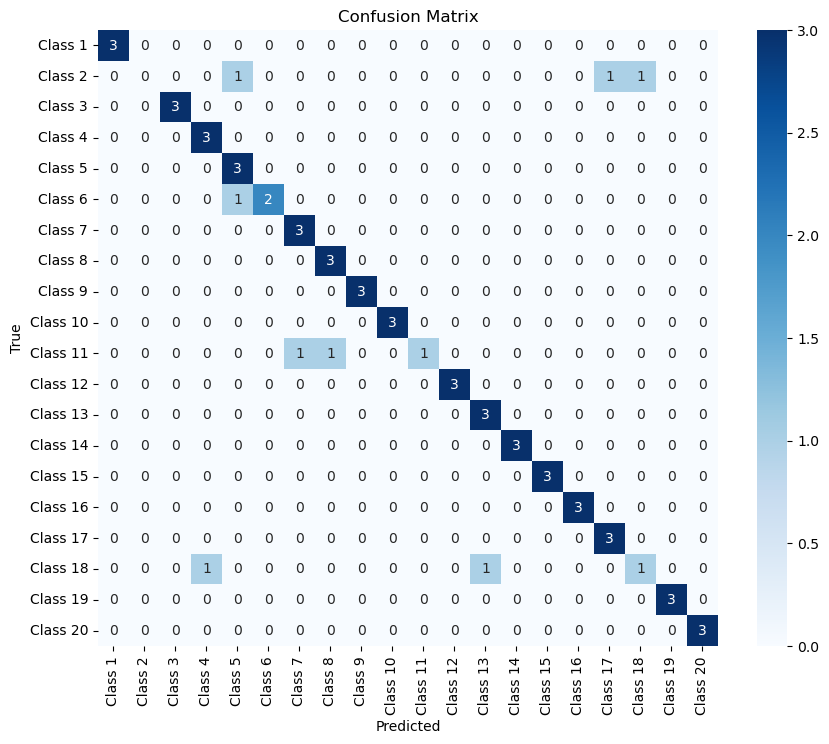

In [18]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize and fit the KNN classifier
clf = KNeighborsClassifier(n_neighbors=1, metric='manhattan', weights='uniform')
clf.fit(train_all_features_multiple, train_label_np)

# Predict and calculate accuracy
predictions = clf.predict(test_all_features_multiple)
accuracy = accuracy_score(test_label, predictions)

# Print predictions and accuracy
print(f"Predictions: {predictions}")
print(f"Accuracy: {accuracy * 100:.2f}%")

# Calculate additional metrics
conf_matrix = confusion_matrix(test_label, predictions)
f1 = f1_score(test_label, predictions, average='weighted')  # Use 'weighted' for multiclass
recall = recall_score(test_label, predictions, average='weighted')  # Use 'weighted' for multiclass
precision = precision_score(test_label, predictions, average='weighted')  # Use 'weighted' for multiclass

# Print the results
print("\nConfusion Matrix:")
print(conf_matrix)
print(f"\nF1-Score: {f1:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Precision: {precision:.4f}")

# Plot the confusion matrix
num_classes = len(np.unique(train_label_np))  # Number of unique classes
class_names = [f"Class {i+1}" for i in range(num_classes)]

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()